# Employee Turnover Risk Prediction Pipeline (5 Parts)

This notebook is organized into 5 parts:
1. **Part 1**: Data filtering and cleaning, with SMOTE strategy definition for imbalance handling.
2. **Part 2**: Text processing in two blocks (`headline` determines direction; `pros/cons` determines intensity via SBERT+PCA).
3. **Part 3**: Feature engineering and feature selection (including PCA).
4. **Part 4**: Model training, evaluation, and result export.
5. **Part 5**: Turnover reason analysis (Cons multi-class classification) to identify key dissatisfaction categories.

**Modeling Logic:**
- First predict `rating_class` (1-5 scale).
- Then convert predicted ratings to turnover risk: `1-2 => risk=1`, `3-5 => risk=0`.
- Finally analyze `cons` text from high-risk employees to identify primary turnover reasons.

## Part 1.1: Data Filtering and Cleaning

This part handles data loading and initial cleaning/filtering:
- Load Glassdoor employee review dataset.
- Filter to Finance Top 5 companies (J.P. Morgan, Citi, HSBC, Barclays, American Express).
- Validate required fields exist.
- Clean text fields and numeric rating fields.
- **Filter empty cons**: Remove records with empty cons (cannot analyze turnover reasons).
- Construct target labels: `rating_class` (1-5) and derived `target_risk` (binary).

**Methods**
- Use `Pandas/NumPy` for data loading and basic statistics.
- Use `to_numeric` and `to_datetime` for field type standardization.
- Perform missing value handling and rule-based mapping for supervised learning label engineering (multi-class + derived binary labels).

In [10]:
# Part 1.1 | Data Import and Usable-Data Filtering
import os
import re
from pathlib import Path

# Avoid Windows locale decoding issues in joblib/loky CPU detection.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path('glassdoor_reviews.csv')
NRC_PATH = Path('NRC-Emotion-Lexicon-Wordlevel-v0.92.txt')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing data file: {DATA_PATH}')
if not NRC_PATH.exists():
    raise FileNotFoundError(f'Missing NRC lexicon file: {NRC_PATH}')

df = pd.read_csv(DATA_PATH)

# ============ Filter to Finance Top 5 Companies ============
FINANCE_TOP5 = [
    'J-P-Morgan',       # 25,814
    'Citi',             # 18,726
    'HSBC-Holdings',    # 13,893
    'Barclays',         # 9,710
    'American-Express', # 9,349
]
# Total approximately 77,492 reviews

df = df[df['firm'].isin(FINANCE_TOP5)].reset_index(drop=True)
print(f'Filtered to Finance Top 5: {df["firm"].nunique()} companies, {len(df)} reviews')
print(df['firm'].value_counts())
# ================================================

required_cols = ['headline', 'pros', 'cons', 'overall_rating']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}. Available: {list(df.columns)}')

text_cols = ['headline', 'pros', 'cons']
for c in text_cols:
    df[c] = df[c].fillna('').astype(str)

# Filter empty cons (cannot analyze turnover reasons)
df = df[df['cons'].str.strip() != ''].reset_index(drop=True)
print(f'After filtering empty cons: {len(df)} reviews')

structured_numeric_cols = [
    'work_life_balance',
    'culture_values',
    'diversity_inclusion',
    'career_opp',
    'comp_benefits',
    'senior_mgmt',
]
structured_categorical_cols = ['current', 'recommend', 'ceo_approv', 'outlook']
high_card_categorical_cols = ['firm', 'job_title', 'location']

for c in structured_numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

if 'date_review' in df.columns:
    df['date_review'] = pd.to_datetime(df['date_review'], errors='coerce')
    df['review_year'] = df['date_review'].dt.year
    df['review_month'] = df['date_review'].dt.month
else:
    df['review_year'] = np.nan
    df['review_month'] = np.nan

df['overall_rating'] = pd.to_numeric(df['overall_rating'], errors='coerce')
df = df.dropna(subset=['overall_rating']).copy()

# Main target is rating (1-5), risk is derived at the end.
df['rating_class'] = np.clip(np.rint(df['overall_rating']).astype(int), 1, 5)
df['target_risk'] = (df['rating_class'] <= 2).astype(int)

print(f'\nData shape: {df.shape}')
print('rating_class distribution:')
print(df['rating_class'].value_counts().sort_index())
print('target_risk distribution (1=risk, 0=no-risk):')
print(df['target_risk'].value_counts().sort_index())

Filtered to Finance Top 5: 5 companies, 77492 reviews
firm
J-P-Morgan          25814
Citi                18726
HSBC-Holdings       13893
Barclays             9710
American-Express     9349
Name: count, dtype: int64
After filtering empty cons: 77491 reviews

Data shape: (77491, 22)
rating_class distribution:
rating_class
1     4510
2     7067
3    19714
4    27755
5    18445
Name: count, dtype: int64
target_risk distribution (1=risk, 0=no-risk):
target_risk
0    65914
1    11577
Name: count, dtype: int64


## Part 1.2: Imbalance Handling (SMOTE Strategy Definition)

This part defines SMOTE handling strategy:
- Define `apply_smote_multiclass` function.
- Automatically set `k_neighbors` based on minimum class sample count to avoid invalid parameters.
- SMOTE is applied to training data in Part 3.2 (after train/test split, before PCA).

**Methods**
- Use `imblearn.over_sampling.SMOTE` for multi-class sample balancing.
- Dynamically adjust `k_neighbors` based on training set minimum class count for stability.
- Strictly execute oversampling on training set to avoid test set information leakage.

In [11]:
# Part 1.2 | Imbalance Handling with SMOTE
from imblearn.over_sampling import SMOTE

USE_SMOTE = True
SMOTE_SAMPLING_STRATEGY = 'auto'  # oversample all minority classes to majority size
SMOTE_MAX_K_NEIGHBORS = 5

def apply_smote_multiclass(X_train_in: pd.DataFrame, y_train_in: pd.Series):
    class_counts = y_train_in.value_counts().sort_index()
    min_class_count = int(class_counts.min())

    if min_class_count <= 1:
        print('SMOTE skipped: at least one class has <=1 sample in training set.')
        return X_train_in.copy(), y_train_in.copy(), None

    k_neighbors = min(SMOTE_MAX_K_NEIGHBORS, min_class_count - 1)

    # Store original dtypes and convert boolean columns to int
    original_dtypes = X_train_in.dtypes
    X_train_converted = X_train_in.copy()
    bool_cols = X_train_converted.select_dtypes(include=['bool', 'boolean']).columns.tolist()
    
    for col in bool_cols:
        X_train_converted[col] = X_train_converted[col].astype(int)

    smote = SMOTE(
        sampling_strategy=SMOTE_SAMPLING_STRATEGY,
        k_neighbors=k_neighbors,
        random_state=RANDOM_STATE
    )

    X_res, y_res = smote.fit_resample(X_train_converted, y_train_in)
    X_res = pd.DataFrame(X_res, columns=X_train_in.columns)
    
    # Convert boolean columns back (round interpolated values first)
    for col in bool_cols:
        X_res[col] = X_res[col].round().astype(int)
    
    y_res = pd.Series(y_res, name=y_train_in.name)
    return X_res, y_res, k_neighbors

print('SMOTE enabled:', USE_SMOTE)
print('SMOTE strategy:', SMOTE_SAMPLING_STRATEGY)
print('SMOTE max k_neighbors:', SMOTE_MAX_K_NEIGHBORS)

SMOTE enabled: True
SMOTE strategy: auto
SMOTE max k_neighbors: 5


## Part 2: Text Processing (Two Blocks)

Part 2 is split into two text processing blocks:
- **Block A**: `headline` determines direction (positive/negative).
- **Block B**: `pros/cons` determines intensity (SBERT + PCA).

### Part 2.1 (Block A): Headline Determines Direction

This block only uses `headline`:
- Use NRC sentiment lexicon to calculate emotion features from `headline`.
- Determine direction based on sign of `headline_net` (+1/-1/0).

**Methods**
- Use NRC lexicon-based sentiment analysis for lightweight emotion detection.
- Use regex tokenization to extract tokens and calculate positive/negative word counts and ratios.
- Map sentiment net value to discrete direction features (positive/negative/neutral) via rule-based function.

In [12]:
# Part 2.1 (Block A) | Headline decides direction

def load_nrc_pos_neg_words(nrc_path: Path):
    nrc = pd.read_csv(
        nrc_path,
        sep='\t',
        header=None,
        names=['word', 'emotion', 'flag']
    )
    nrc = nrc[(nrc['flag'] == 1) & (nrc['emotion'].isin(['positive', 'negative']))]

    pos_words = set(nrc.loc[nrc['emotion'] == 'positive', 'word'].astype(str).str.lower())
    neg_words = set(nrc.loc[nrc['emotion'] == 'negative', 'word'].astype(str).str.lower())
    return pos_words, neg_words

TOKEN_RE = re.compile(r"[A-Za-z']+")

def tokenize(text: str):
    return TOKEN_RE.findall(str(text).lower())

def sentiment_features(text: str, pos_words: set, neg_words: set):
    tokens = tokenize(text)
    total = len(tokens)

    if total == 0:
        return {
            'token_count': 0,
            'pos_cnt': 0,
            'neg_cnt': 0,
            'pos_ratio': 0.0,
            'neg_ratio': 0.0,
            'net': 0.0,
            'abs_strength': 0.0,
        }

    pos_cnt = sum(1 for t in tokens if t in pos_words)
    neg_cnt = sum(1 for t in tokens if t in neg_words)

    pos_ratio = pos_cnt / total
    neg_ratio = neg_cnt / total
    net = pos_ratio - neg_ratio
    abs_strength = abs(net)

    return {
        'token_count': total,
        'pos_cnt': pos_cnt,
        'neg_cnt': neg_cnt,
        'pos_ratio': pos_ratio,
        'neg_ratio': neg_ratio,
        'net': net,
        'abs_strength': abs_strength,
    }

pos_words, neg_words = load_nrc_pos_neg_words(NRC_PATH)
print(f'Loaded NRC words -> positive: {len(pos_words)}, negative: {len(neg_words)}')

headline_feats = df['headline'].apply(lambda x: sentiment_features(x, pos_words, neg_words)).apply(pd.Series)
headline_feats.columns = [f'headline_{c}' for c in headline_feats.columns]

df_feat = pd.concat([df, headline_feats], axis=1)

# Direction from headline only: +1 positive, -1 negative, 0 neutral.
df_feat['headline_direction'] = np.where(
    df_feat['headline_net'] > 0,
    1,
    np.where(df_feat['headline_net'] < 0, -1, 0)
).astype(int)

print('Headline direction distribution:')
print(df_feat['headline_direction'].value_counts().sort_index())

Loaded NRC words -> positive: 2308, negative: 3316
Headline direction distribution:
headline_direction
-1     3979
 0    38933
 1    34579
Name: count, dtype: int64


### Part 2.2 (Block B): Pros/Cons Determine Intensity (SBERT + PCA)

This project designed five progressively stronger unsupervised text factors (Level 1 → Level 5) in independent experiments, from simple statistics to deep semantics. Below we highlight the two core methods used for final comparison:

---

#### Level 3: NMF Topic Decomposition + NRC Sentiment Risk Scoring

**Method Overview**

**NMF (Non-negative Matrix Factorization)** decomposes the TF-IDF matrix $X_{n \times p}$ (all elements ≥ 0) into two non-negative matrices:

$$X \approx W_{n \times k} \cdot H_{k \times p}$$

- $W$: Document-topic matrix, each row represents a document's weight distribution across $k$ topics
- $H$: Topic-word matrix, each row gives the importance of words within a topic

Due to non-negativity constraints, NMF topics are typically more interpretable than SVD because each topic is an additive combination of related words.

**Implementation Steps**
1. Perform NMF decomposition on TF-IDF matrix, extract **10 topics** (`init='nndsvd'` ensures deterministic initialization)
2. For each topic, take top-20 keywords and calculate topic risk score using NRC lexicon:
   - Keywords matching negative/anger/fear/sadness → negative count +1
   - Keywords matching trust → positive count +1
   - **Topic risk = negative count - positive count**
3. For each document, factor = topic weight vector $w_i$ dot product with topic risk vector $r$:
$$\text{factor}_i = \sum_{k=1}^{10} W_{ik} \cdot r_k$$

---

#### Level 4: SBERT + PCA (Deep Semantic Embedding)

**Method Overview**

**SBERT (Sentence-BERT)** is a BERT-based sentence embedding model, fine-tuned on NLI (Natural Language Inference) and STS (Semantic Textual Similarity) tasks, enabling fixed-length vectors to capture sentence-level semantics. This project uses `all-MiniLM-L6-v2` (6-layer Transformer, 384-dimensional output).

**Key Differences from TF-IDF:**
- TF-IDF is a **Bag-of-Words model**, ignores word order and context
- SBERT is **context-aware**, capturing deep semantics: word order, polysemy, negation, phrase collocations, etc.

**PCA (Principal Component Analysis)** performs orthogonal linear transformation on 384-dim SBERT embeddings, with the first principal component representing the most significant semantic contrast axis.

**Implementation Steps**
1. Load pre-trained model `all-MiniLM-L6-v2`, encode `pros` and `cons` into 384-dimensional vectors
2. Apply PCA to embedding matrix, take **first principal component** as semantic intensity factor
3. Use z-score standardization to synthesize final attitude factor

---

#### Method Selection Experiment Results

| Method | Core Approach | Macro-F1 | Weighted-F1 |
|--------|---------------|----------|-------------|
| **Level 3: NMF + NRC** | Topic-level sentiment: decompose topics first, then score topics with lexicon | 0.213 | 0.232 |
| **Level 4: SBERT + PCA** | Deep semantics: Transformer encodes sentence vectors, PCA extracts main axis | 0.213 | **0.244** |

**Final Choice: SBERT + PCA (Level 4):**
- Weighted-F1 is optimal (0.244), Macro-F1 is tied (0.213)
- Transformer captures word order, negation, phrase collocations and other deep semantics, breaking through Bag-of-Words limitations
- Exceeds random baseline by approximately **13%-15%** (random baseline Macro-F1 ≈ 0.185, Weighted-F1 ≈ 0.215)

---

#### Project Implementation

- Use `all-MiniLM-L6-v2` to encode `pros` and `cons` into 384-dimensional sentence vectors
- PCA takes first principal component as semantic intensity (`pros_sbert_pc1`, `cons_sbert_pc1`)
- Synthesize `semantic_attitude_factor` = direction(headline) × intensity(pros/cons)

**Methods**
- Use `SentenceTransformer` for contextual semantic vectorization (pre-trained Transformer representation learning)
- Use `PCA(n_components=1)` to extract semantic main axis and construct intensity features
- Use z-score standardization and rule fusion to achieve "direction-intensity" decoupling before synthesizing single semantic attitude factor

In [13]:
# Part 2.2 (Block B) | Pros/Cons decide strength via SBERT + PCA
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'
SBERT_BATCH_SIZE = 128

def robust_zscore(x: np.ndarray):
    x = np.asarray(x, dtype=float)
    std = x.std()
    if std < 1e-12:
        return np.zeros_like(x, dtype=float)
    return (x - x.mean()) / std

sbert_model = SentenceTransformer(SBERT_MODEL_NAME)

pros_texts = df_feat['pros'].fillna('').astype(str).tolist()
cons_texts = df_feat['cons'].fillna('').astype(str).tolist()

pros_emb = sbert_model.encode(
    pros_texts,
    batch_size=SBERT_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
cons_emb = sbert_model.encode(
    cons_texts,
    batch_size=SBERT_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

pca_pros = PCA(n_components=1, random_state=RANDOM_STATE)
pca_cons = PCA(n_components=1, random_state=RANDOM_STATE)

pros_pc1 = pca_pros.fit_transform(pros_emb).ravel()
cons_pc1 = pca_cons.fit_transform(cons_emb).ravel()

df_feat['pros_sbert_pc1'] = pros_pc1
df_feat['cons_sbert_pc1'] = cons_pc1

df_feat['pros_semantic_strength'] = np.abs(robust_zscore(pros_pc1))
df_feat['cons_semantic_strength'] = np.abs(robust_zscore(cons_pc1))

# Headline gives direction, pros/cons gives magnitude.
fallback_direction = np.where(
    df_feat['pros_semantic_strength'] >= df_feat['cons_semantic_strength'],
    1,
    -1
)

df_feat['text_direction'] = np.where(
    df_feat['headline_direction'] == 0,
    fallback_direction,
    df_feat['headline_direction']
).astype(int)

df_feat['direction_is_positive'] = (df_feat['text_direction'] == 1).astype(int)
df_feat['direction_is_negative'] = (df_feat['text_direction'] == -1).astype(int)
df_feat['direction_is_from_headline'] = (df_feat['headline_direction'] != 0).astype(int)

df_feat['selected_semantic_strength'] = np.where(
    df_feat['text_direction'] == 1,
    df_feat['pros_semantic_strength'],
    df_feat['cons_semantic_strength']
)

df_feat['semantic_attitude_factor'] = df_feat['text_direction'] * df_feat['selected_semantic_strength']

print('SBERT model:', SBERT_MODEL_NAME)
print('Pros embedding shape:', pros_emb.shape)
print('Cons embedding shape:', cons_emb.shape)
print('Text direction distribution (after fallback):')
print(df_feat['text_direction'].value_counts().sort_index())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/606 [00:00<?, ?it/s]

Batches:   0%|          | 0/606 [00:00<?, ?it/s]

SBERT model: all-MiniLM-L6-v2
Pros embedding shape: (77491, 384)
Cons embedding shape: (77491, 384)
Text direction distribution (after fallback):
text_direction
-1    23178
 1    54313
Name: count, dtype: int64


## Part 3: Feature Engineering and Selection (Two Parts)

Part 3 is split into two sub-parts:
- **Part 3.1**: Feature engineering and feature expansion.
- **Part 3.2**: Feature selection (including PCA) and training data preparation.

### Part 3.1: Feature Engineering and Expansion

This sub-part is responsible for constructing candidate features:
- Use direction features and SBERT semantic intensity features from Part 2.
- Merge structured features with high-cardinality field frequency encoding features.
- One-hot encode categorical features, impute numeric missing values.
- Form candidate feature matrix `X_full`.

**Methods**
- Perform multi-source feature fusion (text semantic features + structured business features).
- Use frequency encoding for high-cardinality categorical variables to reduce dimension explosion risk.
- One-hot encode low-cardinality categories, use median imputation for numeric missing values.

In [14]:
print("Shape:", df_feat.shape)
print("Columns example:", df_feat.columns)

Shape: (77491, 40)
Columns example: Index(['firm', 'date_review', 'job_title', 'current', 'location',
       'overall_rating', 'work_life_balance', 'culture_values',
       'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt',
       'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons',
       'review_year', 'review_month', 'rating_class', 'target_risk',
       'headline_token_count', 'headline_pos_cnt', 'headline_neg_cnt',
       'headline_pos_ratio', 'headline_neg_ratio', 'headline_net',
       'headline_abs_strength', 'headline_direction', 'pros_sbert_pc1',
       'cons_sbert_pc1', 'pros_semantic_strength', 'cons_semantic_strength',
       'text_direction', 'direction_is_positive', 'direction_is_negative',
       'direction_is_from_headline', 'selected_semantic_strength',
       'semantic_attitude_factor'],
      dtype='object')


In [15]:
df_model = df_feat.copy()

In [16]:
# 3.1 Define subratings + build engineered features
subrating_cols = [
    "work_life_balance",
    "culture_values",
    "diversity_inclusion",
    "career_opp",
    "comp_benefits",
    "senior_mgmt",
]

# 1) dissatisfaction index (higher = worse)
# fillna(3) is a neutral middle point
subratings_filled = df_model[subrating_cols].fillna(3)
df_model["dissatisfaction_index"] = (5 - subratings_filled).sum(axis=1)

# 2) summary stats
df_model["subrating_mean"] = subratings_filled.mean(axis=1)
df_model["subrating_std"] = subratings_filled.std(axis=1)

# 3) gap features (interpretable)
df_model["career_minus_comp"] = df_model["career_opp"] - df_model["comp_benefits"]
df_model["mgmt_minus_culture"] = df_model["senior_mgmt"] - df_model["culture_values"]

In [17]:
# Interaction features (structured x text)
# Uses semantic_attitude_factor from Part 2
df_model["text_x_dissatisfaction"] = (
    df_model["semantic_attitude_factor"] *
    df_model["dissatisfaction_index"]
)

df_model["text_x_subrating_mean"] = (
    df_model["semantic_attitude_factor"] *
    df_model["subrating_mean"]
)

In [18]:
# 3.3 Build Feature Matrix
# Time columns (from Part 1)
time_cols = [c for c in ["review_year", "review_month"] if c in df_model.columns]

# Text numeric features from Part 2
text_numeric_cols = [
    # Headline NRC block
    'headline_token_count',
    'headline_pos_cnt',
    'headline_neg_cnt',
    'headline_pos_ratio',
    'headline_neg_ratio',
    'headline_net',
    'headline_abs_strength',
    'headline_direction',

    # SBERT + PCA block
    'pros_sbert_pc1',
    'cons_sbert_pc1',
    'pros_semantic_strength',
    'cons_semantic_strength',

    # fused signals
    'text_direction',
    'direction_is_positive',
    'direction_is_negative',
    'direction_is_from_headline',
    'selected_semantic_strength',
    'semantic_attitude_factor',
]
text_numeric_cols = [c for c in text_numeric_cols if c in df_model.columns]

# Engineered numeric features (from 3.1)
engineered_cols = [
    "dissatisfaction_index",
    "subrating_mean",
    "subrating_std",
    "career_minus_comp",
    "mgmt_minus_culture",
    "text_x_dissatisfaction",
    "text_x_subrating_mean",
]
engineered_cols = [c for c in engineered_cols if c in df_model.columns]

# Final numeric columns (overall_rating excluded to avoid leakage)
numeric_cols = subrating_cols + time_cols + text_numeric_cols + engineered_cols
numeric_cols = list(dict.fromkeys(numeric_cols))

print("Numeric feature count:", len(numeric_cols))

Numeric feature count: 33


In [19]:
# 3.4 High-cardinality categorical -> frequency encoding

high_card_cols = [c for c in ["firm", "job_title", "location"] if c in df_model.columns]

for col in high_card_cols:
    s = df_model[col].astype("string").fillna("MISSING")
    freq = s.value_counts(normalize=True)
    df_model[f"{col}_freq"] = s.map(freq).astype(float)

freq_cols = [f"{col}_freq" for col in high_card_cols]
print("Frequency encoded cols:", freq_cols)

Frequency encoded cols: ['firm_freq', 'job_title_freq', 'location_freq']


In [20]:
# 3.5 Categorical encoding - one hot
low_card_cols = [c for c in ["current", "recommend", "ceo_approv", "outlook"] if c in df_model.columns]

for col in low_card_cols:
    df_model[col] = df_model[col].astype("string").fillna("MISSING")

X_cat = pd.get_dummies(df_model[low_card_cols], drop_first=False) if low_card_cols else pd.DataFrame(index=df_model.index)
print("One-hot categorical shape:", X_cat.shape)

One-hot categorical shape: (77491, 25)


In [21]:
# 3.6 Assemble X_full (median impute + drop constants)

# Numeric matrix
final_num_cols = [c for c in (numeric_cols + freq_cols) if c in df_model.columns]
X_num = df_model[final_num_cols].copy()

# Coerce to numeric
X_num = X_num.apply(pd.to_numeric, errors="coerce")

# Median impute
X_num = X_num.fillna(X_num.median(numeric_only=True))

# Concatenate numeric + categorical
X_full = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

# Drop constant columns
X_full = X_full.loc[:, X_full.nunique() > 1]

print("X_full shape:", X_full.shape)

X_full shape: (77491, 61)


In [22]:
from sklearn.model_selection import train_test_split

y = df_model["rating_class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts().sort_index())

Train: (61992, 61) Test: (15499, 61)
y_train distribution:
 rating_class
1     3608
2     5653
3    15771
4    22204
5    14756
Name: count, dtype: int64


### Part 3.2: Feature Selection (PCA) and Training Data Preparation

This sub-part handles selection and modeling input preparation:
- First remove constant features.
- Perform train/test split (80:20 stratified sampling).
- Execute PCA for dimensionality reduction (retain 95% variance explained).

**Methods**
- First perform variance filtering (remove constant columns) to reduce ineffective feature interference.
- Use stratified sampling `train_test_split(stratify=y)` to maintain class distribution consistency.
- Use `StandardScaler + PCA(95% explained variance)` for dimensionality reduction.

In [23]:
# Standardize + PCA(95%) -> X_train_final/X_test_final
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Apply SMOTE to training data (before scaling/PCA)
if USE_SMOTE:
    print("Applying SMOTE to training data...")
    print(f"Before SMOTE - X_train shape: {X_train.shape}")
    print(f"Before SMOTE - y_train distribution:\n{y_train.value_counts().sort_index()}")
    
    X_train_smote, y_train_smote, k_used = apply_smote_multiclass(X_train, y_train)
    
    print(f"\nAfter SMOTE - X_train shape: {X_train_smote.shape}")
    print(f"After SMOTE - y_train distribution:\n{y_train_smote.value_counts().sort_index()}")
    print(f"SMOTE k_neighbors used: {k_used}")
else:
    X_train_smote = X_train.copy()
    y_train_smote = y_train.copy()
    print("SMOTE disabled, using original training data.")

# Update y_train for model training
y_train = y_train_smote

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_final = pca.fit_transform(X_train_scaled)
X_test_final = pca.transform(X_test_scaled)

X_test_selected = X_test.copy()
X_test_model = X_test_selected.copy()
test_index = X_test.index

print("\nPCA components:", X_train_final.shape[1])
print("Explained variance sum:", pca.explained_variance_ratio_.sum())
print("Final matrices:", X_train_final.shape, X_test_final.shape)

Applying SMOTE to training data...
Before SMOTE - X_train shape: (61992, 61)
Before SMOTE - y_train distribution:
rating_class
1     3608
2     5653
3    15771
4    22204
5    14756
Name: count, dtype: int64

After SMOTE - X_train shape: (111020, 61)
After SMOTE - y_train distribution:
rating_class
1    22204
2    22204
3    22204
4    22204
5    22204
Name: count, dtype: int64
SMOTE k_neighbors used: 5

PCA components: 39
Explained variance sum: 0.9513156967372204
Final matrices: (111020, 39) (15499, 39)


## Part 4: Model Selection, Evaluation, and Visualization

Part 4 is split into two sub-parts:
- **Part 4.1**: Model selection and training.
- **Part 4.2**: Metrics calculation, visualization, and result export.

In [24]:
# Part 4.0 | Train All Models and Generate Comparison Table (Binary Risk Classification)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from xgboost import XGBClassifier

# Store results
model_results = []
y_test_risk = (y_test <= 2).astype(int)

# ============ Model 1: Logistic Regression ============
print("Training Logistic Regression...")
lr_model = LogisticRegression(solver='lbfgs', C=1.0, max_iter=3000, n_jobs=-1)
lr_model.fit(X_train_final, y_train.astype(int))
lr_pred = lr_model.predict(X_test_final)
lr_proba = lr_model.predict_proba(X_test_final)

lr_pred_risk = (lr_pred <= 2).astype(int)
lr_risk_prob = lr_proba[:, 0] + lr_proba[:, 1]  # P(rating<=2)

lr_acc = accuracy_score(y_test_risk, lr_pred_risk)
lr_precision = precision_score(y_test_risk, lr_pred_risk)
lr_recall = recall_score(y_test_risk, lr_pred_risk)
lr_f1 = f1_score(y_test_risk, lr_pred_risk)
lr_auc = roc_auc_score(y_test_risk, lr_risk_prob)

model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': lr_acc,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'AUC-ROC': lr_auc
})
print(f"  Acc: {lr_acc:.4f}, F1: {lr_f1:.4f}, AUC: {lr_auc:.4f}")

# ============ Model 2: XGBoost ============
print("Training XGBoost...")
xgb_model = XGBClassifier(
    objective='multi:softprob', num_class=5, n_estimators=500,
    learning_rate=0.05, max_depth=6, min_child_weight=3,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    eval_metric='mlogloss', tree_method='hist',
    random_state=RANDOM_STATE, n_jobs=-1
)
y_train_xgb = y_train.astype(int) - 1
xgb_model.fit(X_train_final, y_train_xgb)
xgb_pred = xgb_model.predict(X_test_final).astype(int) + 1
xgb_proba = xgb_model.predict_proba(X_test_final)

xgb_pred_risk = (xgb_pred <= 2).astype(int)
xgb_risk_prob = xgb_proba[:, 0] + xgb_proba[:, 1]

xgb_acc = accuracy_score(y_test_risk, xgb_pred_risk)
xgb_precision = precision_score(y_test_risk, xgb_pred_risk)
xgb_recall = recall_score(y_test_risk, xgb_pred_risk)
xgb_f1 = f1_score(y_test_risk, xgb_pred_risk)
xgb_auc = roc_auc_score(y_test_risk, xgb_risk_prob)

model_results.append({
    'Model': 'XGBoost',
    'Accuracy': xgb_acc,
    'Precision': xgb_precision,
    'Recall': xgb_recall,
    'F1-Score': xgb_f1,
    'AUC-ROC': xgb_auc
})
print(f"  Acc: {xgb_acc:.4f}, F1: {xgb_f1:.4f}, AUC: {xgb_auc:.4f}")

# ============ Model 3: MLP Neural Network ============
print("Training MLP...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
    alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
    max_iter=200, early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=20, random_state=RANDOM_STATE, verbose=False
)
mlp_model.fit(X_train_final, y_train.astype(int))
mlp_pred = mlp_model.predict(X_test_final)
mlp_proba = mlp_model.predict_proba(X_test_final)

mlp_pred_risk = (mlp_pred <= 2).astype(int)
mlp_risk_prob = mlp_proba[:, 0] + mlp_proba[:, 1]

mlp_acc = accuracy_score(y_test_risk, mlp_pred_risk)
mlp_precision = precision_score(y_test_risk, mlp_pred_risk)
mlp_recall = recall_score(y_test_risk, mlp_pred_risk)
mlp_f1 = f1_score(y_test_risk, mlp_pred_risk)
mlp_auc = roc_auc_score(y_test_risk, mlp_risk_prob)

model_results.append({
    'Model': 'MLP',
    'Accuracy': mlp_acc,
    'Precision': mlp_precision,
    'Recall': mlp_recall,
    'F1-Score': mlp_f1,
    'AUC-ROC': mlp_auc
})
print(f"  Acc: {mlp_acc:.4f}, F1: {mlp_f1:.4f}, AUC: {mlp_auc:.4f}")

# ============ Create DataFrame and Display ============
results_df = pd.DataFrame(model_results)
print("\n" + "=" * 80)
print("Binary Classification: Turnover Risk Detection (High-Risk = Rating <= 2)")
print("=" * 80)
print(results_df.to_string(index=False))

# ============ Generate LaTeX Table ============
latex_table = r"""\begin{table}[htbp]
\centering
\caption{Model Performance Comparison for Turnover Risk Detection (Binary Classification)}
\label{tab:model_comparison}
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{AUC-ROC} \\
\midrule
"""

for _, row in results_df.iterrows():
    latex_table += f"{row['Model']} & {row['Accuracy']:.3f} & {row['Precision']:.3f} & {row['Recall']:.3f} & {row['F1-Score']:.3f} & {row['AUC-ROC']:.3f} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\end{table}"""

print("\n" + "=" * 80)
print("LaTeX Table (copy to paper):")
print("=" * 80)
print(latex_table)

# Find best model
best_idx = results_df['F1-Score'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
print(f"\n*** Best Model: {best_model} ***")
print(f"    Accuracy:  {results_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"    Precision: {results_df.loc[best_idx, 'Precision']:.4f}")
print(f"    Recall:    {results_df.loc[best_idx, 'Recall']:.4f}")
print(f"    F1-Score:  {results_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"    AUC-ROC:   {results_df.loc[best_idx, 'AUC-ROC']:.4f}")

Training Logistic Regression...
  Acc: 0.9170, F1: 0.7079, AUC: 0.9413
Training XGBoost...
  Acc: 0.9207, F1: 0.7191, AUC: 0.9486
Training MLP...
  Acc: 0.9118, F1: 0.6933, AUC: 0.9378

Binary Classification: Turnover Risk Detection (High-Risk = Rating <= 2)
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.917027   0.746884 0.672712  0.707860 0.941260
            XGBoost  0.920705   0.763963 0.679188  0.719086 0.948591
                MLP  0.911801   0.721625 0.667098  0.693291 0.937791

LaTeX Table (copy to paper):
\begin{table}[htbp]
\centering
\caption{Model Performance Comparison for Turnover Risk Detection (Binary Classification)}
\label{tab:model_comparison}
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1-Score} & \textbf{AUC-ROC} \\
\midrule
Logistic Regression & 0.917 & 0.747 & 0.673 & 0.708 & 0.941 \\
XGBoost & 0.921 & 0.764 & 0.679 & 0.719 & 0.949 \\
MLP & 0.912 

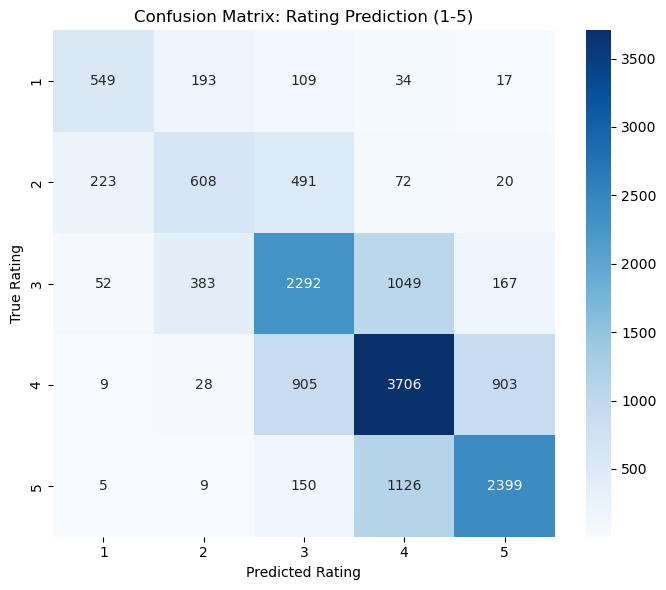

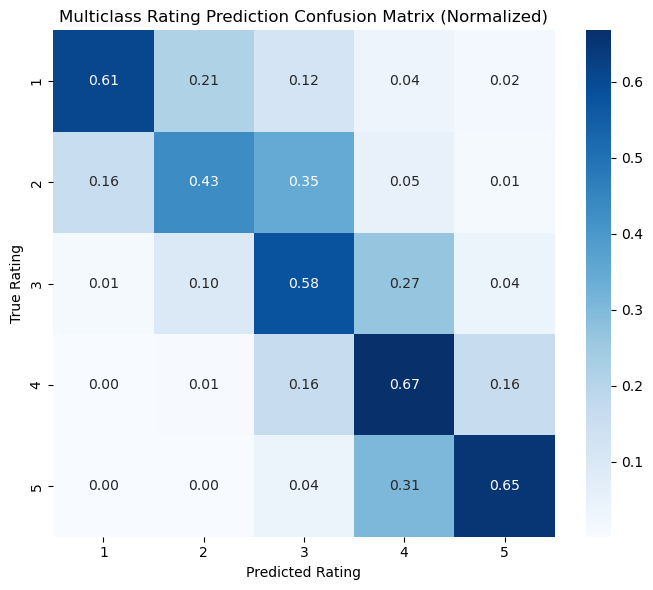

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Rating confusion matrix (counts)
labels_rating = [1, 2, 3, 4, 5]
cm_rating = confusion_matrix(y_test, y_pred_rating, labels=labels_rating)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_rating,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_rating,
    yticklabels=labels_rating
)
plt.title('Confusion Matrix: Rating Prediction (1-5)')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

# Rating confusion matrix (row-normalized: recall view)
cm_rating_norm = cm_rating / cm_rating.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_rating_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=labels_rating,
    yticklabels=labels_rating
)
plt.title('Multiclass Rating Prediction Confusion Matrix (Normalized)')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

### Part 4.1: Model Selection and Training

This sub-part is responsible for:
- Training and comparing multiple models: **XGBoost, Logistic Regression, MLP Neural Network**.
- Complete model training.
- Produce test set predictions for subsequent metrics and visualization.

**Methods**
- **XGBoost**: Gradient boosting trees, `multi:softprob` multi-class.
- **Logistic Regression**: Linear classifier, `lbfgs` solver.
- **MLP**: Multi-layer perceptron neural network, `(128, 64)` hidden layers.
- Output both class probabilities and discrete predictions for subsequent risk conversion and evaluation.

In [36]:
# Part 4.1 | Model Selection 1 and Training
# Model choice: XGBoost multi-class for rating_class (1..5).
MODEL_NAME = 'xgboost_multiclass'

model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# map to 0..4 for XGBoost training
y_train_xgb = y_train.astype(int) - 1

model.fit(X_train_final, y_train_xgb)

y_proba = model.predict_proba(X_test_final)
y_pred_rating = model.predict(X_test_final).astype(int) + 1

print('Selected model:', MODEL_NAME)
print('Training samples:', X_train_final.shape[0])
print('Test samples:', X_test_model.shape[0])

Selected model: xgboost_multiclass
Training samples: 111020
Test samples: 15499


In [32]:
# Part 4.1 | Model Selection 2 and Training (Logistic Regression Multiclass)
from sklearn.linear_model import LogisticRegression

MODEL_NAME = 'logreg_multiclass'

# y is 1..5 already; sklearn multiclass supports that directly
model = LogisticRegression(
    solver='lbfgs',
    C=1.0, 
    max_iter=3000,
    n_jobs=-1
)

model.fit(X_train_final, y_train.astype(int))

# predict proba: (n_test, 5) columns correspond to model.classes_
y_proba = model.predict_proba(X_test_final)

# predicted rating: 1..5
y_pred_rating = model.predict(X_test_final).astype(int)

print('Selected model:', MODEL_NAME)
print('Training samples:', X_train_final.shape[0])
print('Test samples:', X_test_final.shape[0])
print('Classes order:', model.classes_)

Selected model: logreg_multiclass
Training samples: 111020
Test samples: 15499
Classes order: [1 2 3 4 5]


In [34]:
# Part 4.1 | Model Selection 3 and Training (Neural Net MLP Multiclass)
from sklearn.neural_network import MLPClassifier

MODEL_NAME = 'mlp_multiclass'

# Tips:
# - If you used PCA=True, data is already scaled in PCA pipeline (StandardScaler was applied before PCA).
# - If PCA=False, MLP still benefits from scaling; but to keep your pipeline unchanged,
#   we rely on your current setup. (If PCA=False, I can give you a minimal scaler wrapper.)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,                 # L2 regularization
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=False
)

model.fit(X_train_final, y_train.astype(int))

y_proba = model.predict_proba(X_test_final)          # (n_test, 5) aligned with model.classes_
y_pred_rating = model.predict(X_test_final).astype(int)

print('Selected model:', MODEL_NAME)
print('Training samples:', X_train_final.shape[0])
print('Test samples:', X_test_final.shape[0])
print('Classes order:', model.classes_)
print('MLP iters:', getattr(model, "n_iter_", None))

Selected model: mlp_multiclass
Training samples: 111020
Test samples: 15499
Classes order: [1 2 3 4 5]
MLP iters: 59


### Part 4.2: Metrics Evaluation and Visualization

This sub-part is responsible for:
- Calculate rating prediction metrics.
- Convert rating predictions to final turnover risk and calculate binary classification metrics.
- Plot risk confusion matrix.
- Export prediction results and model files.

**Methods**
- Use `accuracy/F1/classification_report` for multi-class and binary classification evaluation.
- Map multi-class predictions to turnover risk predictions via business rules (rating threshold).
- Use `seaborn` to visualize confusion matrix, save CSV predictions and `joblib` model files.

Rating Prediction Metrics (1-5):
Accuracy:     0.6164
Macro-F1:     0.5966
Weighted-F1:  0.6154

Rating Classification Report:
              precision    recall  f1-score   support

           1     0.6551    0.6086    0.6310       902
           2     0.4980    0.4300    0.4615      1414
           3     0.5807    0.5813    0.5810      3943
           4     0.6190    0.6676    0.6424      5551
           5     0.6843    0.6503    0.6669      3689

    accuracy                         0.6164     15499
   macro avg     0.6074    0.5876    0.5966     15499
weighted avg     0.6158    0.6164    0.6154     15499


Final Risk Metrics (derived from predicted rating):
Accuracy:     0.9207
Binary-F1:    0.7191
Macro-F1:     0.8365
Weighted-F1:  0.9188

Risk Classification Report (0=no-risk, 1=risk):
              precision    recall  f1-score   support

           0     0.9447    0.9631    0.9538     13183
           1     0.7640    0.6792    0.7191      2316

    accuracy                      

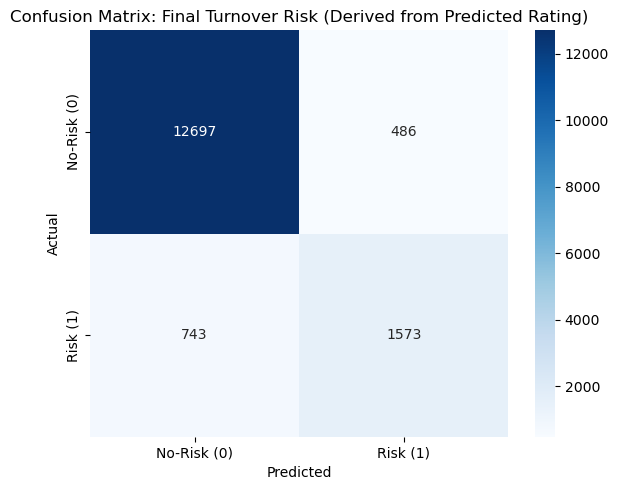

Predictions saved: outputs/turnover_risk_from_rating_predictions.csv
Model saved:       outputs/overall_rating_xgboost.joblib


In [37]:
# Part 4.2 | Metrics, Visualization, and Export
# Step A: rating metrics
rating_acc = accuracy_score(y_test, y_pred_rating)
rating_macro_f1 = f1_score(y_test, y_pred_rating, average='macro')
rating_weighted_f1 = f1_score(y_test, y_pred_rating, average='weighted')

print('Rating Prediction Metrics (1-5):')
print(f'Accuracy:     {rating_acc:.4f}')
print(f'Macro-F1:     {rating_macro_f1:.4f}')
print(f'Weighted-F1:  {rating_weighted_f1:.4f}')
print()
print('Rating Classification Report:')
print(classification_report(y_test, y_pred_rating, digits=4))

# Step B: convert predicted rating -> final binary risk
y_test_risk = (y_test <= 2).astype(int)
y_pred_risk = (y_pred_rating <= 2).astype(int)
y_pred_risk_prob = y_proba[:, 0] + y_proba[:, 1]

risk_acc = accuracy_score(y_test_risk, y_pred_risk)
risk_binary_f1 = f1_score(y_test_risk, y_pred_risk, average='binary')
risk_macro_f1 = f1_score(y_test_risk, y_pred_risk, average='macro')
risk_weighted_f1 = f1_score(y_test_risk, y_pred_risk, average='weighted')

print()
print('Final Risk Metrics (derived from predicted rating):')
print(f'Accuracy:     {risk_acc:.4f}')
print(f'Binary-F1:    {risk_binary_f1:.4f}')
print(f'Macro-F1:     {risk_macro_f1:.4f}')
print(f'Weighted-F1:  {risk_weighted_f1:.4f}')
print()
print('Risk Classification Report (0=no-risk, 1=risk):')
print(classification_report(y_test_risk, y_pred_risk, digits=4))

# Risk confusion matrix
labels = [0, 1]
cm = confusion_matrix(y_test_risk, y_pred_risk, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No-Risk (0)', 'Risk (1)'],
    yticklabels=['No-Risk (0)', 'Risk (1)']
)
plt.title('Confusion Matrix: Final Turnover Risk (Derived from Predicted Rating)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save artifacts
pred_cols = ['headline', 'pros', 'cons', 'overall_rating', 'rating_class', 'target_risk']
pred_cols += [c for c in structured_numeric_cols if c in df_feat.columns]
pred_cols += [c for c in structured_categorical_cols if c in df_feat.columns]
pred_cols += [c for c in ['review_year', 'review_month', 'firm_freq', 'job_title_freq', 'location_freq'] if c in df_feat.columns]
pred_cols = list(dict.fromkeys(pred_cols))

pred_df = df_feat.loc[test_index, pred_cols].copy()
pred_df['pred_rating'] = y_pred_rating
pred_df['pred_risk'] = y_pred_risk
pred_df['pred_risk_prob'] = y_pred_risk_prob

pred_path = OUTPUT_DIR / 'turnover_risk_from_rating_predictions.csv'
model_path = OUTPUT_DIR / 'overall_rating_xgboost.joblib'

pred_df.to_csv(pred_path, index=False)
joblib.dump(model, model_path)

print(f'Predictions saved: {pred_path}')
print(f'Model saved:       {model_path}')

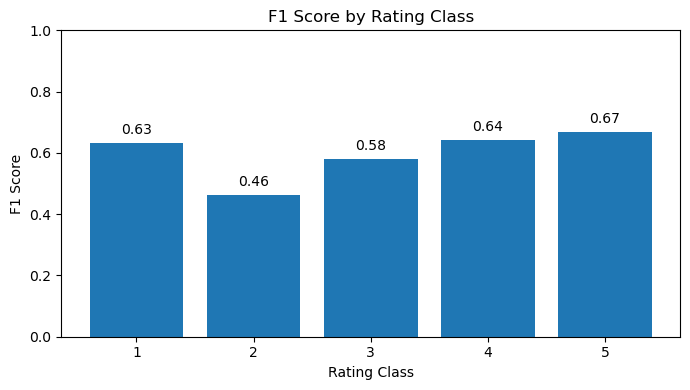

In [41]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report_dict = classification_report(y_test, y_pred_rating, output_dict=True, digits=4)
report_df = pd.DataFrame(report_dict).T

# Only class 1..5
class_rows = [str(i) for i in [1,2,3,4,5]]
f1_per_class = report_df.loc[class_rows, 'f1-score'].astype(float)

plt.figure(figsize=(7,4))

bars = plt.bar(f1_per_class.index, f1_per_class.values)

plt.title('F1 Score by Rating Class')
plt.xlabel('Rating Class')
plt.ylabel('F1 Score')
plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Part 5: Turnover Reason Analysis (Cons Multi-class Classification)

Part 5 performs multi-class classification on employee review `cons` (disadvantages/negative comments) to analyze the main dissatisfaction reasons of high-risk employees.

### Classification Categories
1. **Compensation & Benefits**: Salary, benefits, promotions, etc.
2. **Management & Leadership**: Management, leadership style, decision-making, etc.
3. **Team & Interpersonal**: Colleague relationships, team atmosphere, culture, etc.
4. **Work Environment & Experience**: Work hours, stress, office conditions, etc.

### Methods
1. **Weak Label Generation**: Use keyword rules to generate weak supervision labels for partial data (~66% samples)
2. **Transformer Classifier**:
   - Use SBERT to encode cons text into 384-dimensional vectors
   - Train Logistic Regression classifier with weak-labeled data
   - Predict all data to ensure **100% samples have labels**
3. **Analyze high-risk employees** (rating ≤ 2) main dissatisfaction category distribution

In [ ]:
# Part 5.1 | Define Classification Labels and Keyword Rules

# Four category definitions
CONS_CATEGORIES = {
    0: 'Compensation',   # Compensation & Benefits
    1: 'Management',     # Management & Leadership
    2: 'Team',           # Team & Interpersonal
    3: 'Environment'     # Work Environment & Experience
}

# Keyword rules (for generating weak supervision labels)
CONS_KEYWORDS = {
    0: [  # Compensation & Benefits
        'salary', 'salaries', 'pay', 'wage', 'wages', 'compensation', 'bonus', 'bonuses',
        'benefit', 'benefits', 'insurance', 'healthcare', 'health care', '401k', 'pension',
        'stock', 'equity', 'raise', 'raises', 'underpaid', 'low pay', 'low salary',
        'paid time', 'pto', 'vacation', 'holiday', 'overtime', 'commission',
        'promotion', 'promotions', 'career growth', 'advancement', 'advancement opportunities',
        'no raise', 'merit', 'increment', 'package', 'perks', 'stipend'
    ],
    1: [  # Management & Leadership
        'management', 'manager', 'managers', 'leadership', 'leader', 'leaders',
        'supervisor', 'supervisors', 'boss', 'bosses', 'executive', 'executives',
        'director', 'directors', 'senior management', 'upper management', 'top management',
        'micromanage', 'micromanagement', 'decision', 'decisions', 'bureaucracy',
        'politics', 'political', 'favoritism', 'nepotism', 'transparency',
        'communication', 'direction', 'vision', 'strategy', 'ceo', 'cfo',
        'hierarchy', 'chain of command', 'red tape', 'corporate'
    ],
    2: [  # Team & Interpersonal
        'team', 'teams', 'teammate', 'teammates', 'coworker', 'coworkers', 'co-worker',
        'colleague', 'colleagues', 'collaboration', 'collaborative', 'teamwork',
        'culture', 'toxic', 'atmosphere', 'morale', 'clique', 'cliques',
        'gossip', 'drama', 'conflict', 'conflicts', 'hostile', 'bullying',
        'harassment', 'discrimination', 'diversity', 'inclusion', 'respect',
        'relationship', 'relationships', 'interpersonal', 'social', 'people',
        'attitude', 'attitudes', 'backstabbing', 'competitive environment'
    ],
    3: [  # Work Environment & Experience
        'work life', 'work-life', 'worklife', 'balance', 'hours', 'long hours',
        'overtime', 'overwork', 'overworked', 'burnout', 'stress', 'stressful',
        'pressure', 'deadline', 'deadlines', 'workload', 'work load',
        'office', 'workspace', 'remote', 'wfh', 'work from home', 'commute',
        'location', 'facilities', 'equipment', 'tools', 'technology', 'tech stack',
        'training', 'learning', 'development', 'growth opportunity', 'opportunity',
        'job security', 'stability', 'layoff', 'layoffs', 'restructuring',
        'flexibility', 'schedule', 'shift', 'travel', 'environment', 'conditions'
    ]
}

print('Cons categories defined:')
for cat_id, cat_name in CONS_CATEGORIES.items():
    print(f'  {cat_id}: {cat_name}')

Cons categories defined:
  0: Compensation
  1: Management
  2: Team
  3: Environment


In [ ]:
# Part 5.2 | Generate Weak Labels and Statistics

# Use df_feat directly (Part 1 already filtered empty cons)
df_cons = df_feat.copy()
print(f'Total samples for cons classification: {len(df_cons)}')

# Generate cons classification labels + whether keywords matched
def assign_with_match_info(text):
    text_lower = text.lower()
    scores = {}
    for cat_id, keywords in CONS_KEYWORDS.items():
        score = 0
        for kw in keywords:
            pattern = r'\b' + re.escape(kw) + r'\b'
            matches = len(re.findall(pattern, text_lower))
            score += matches
        scores[cat_id] = score
    
    max_score = max(scores.values())
    if max_score == 0:
        return 3, False  # No keyword match
    
    # Check for tie
    categories_with_max = [cat_id for cat_id, s in scores.items() if s == max_score]
    if len(categories_with_max) > 1:
        return 3, False  # Tie - don't assign, let classifier predict
    
    return categories_with_max[0], True

print('\nGenerating weak labels...')
results = [assign_with_match_info(t) for t in df_cons['cons']]
df_cons['cons_category_weak'] = [r[0] for r in results]
df_cons['has_keyword_match'] = [r[1] for r in results]

# Weak label statistics
matched = df_cons['has_keyword_match'].sum()
unmatched = len(df_cons) - matched

print('\n' + '=' * 60)
print('Weak Label Statistics')
print('=' * 60)
print(f'Total samples: {len(df_cons):,}')
print(f'Matched by keywords (unique winner): {matched:,} ({matched/len(df_cons)*100:.1f}%)')
print(f'No match or tie (to predict): {unmatched:,} ({unmatched/len(df_cons)*100:.1f}%)')

Total samples for cons classification: 77491

Generating weak labels...

Weak Label Statistics
Total samples: 77,491
Matched by keywords (unique winner): 42,309 (54.6%)
No match or tie (to predict): 35,182 (45.4%)


### Part 5.3: SBERT + Classifier Training

Use data with real weak labels (keyword-matched samples) to train a Transformer classifier:
1. Use SBERT to encode cons text into 384-dimensional vectors
2. Train Logistic Regression classifier
3. Predict all data to ensure every sample has a label

In [ ]:
# Part 5.3 | SBERT Encoding + Classifier Training
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Separate labeled data (for training) and unlabeled data (for prediction)
df_labeled = df_cons[df_cons['has_keyword_match'] == True].copy()
df_unlabeled = df_cons[df_cons['has_keyword_match'] == False].copy()

print(f'Labeled samples (for training): {len(df_labeled):,}')
print(f'Unlabeled samples (to predict): {len(df_unlabeled):,}')

# Use previously loaded SBERT model (from Part 2)
print('\nEncoding cons texts with SBERT...')

# Encode all cons texts
all_cons_texts = df_cons['cons'].tolist()
cons_embeddings = sbert_model.encode(
    all_cons_texts,
    batch_size=SBERT_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(f'Cons embeddings shape: {cons_embeddings.shape}')

# Save embedding indices to df_cons
df_cons['cons_emb_idx'] = range(len(df_cons))  # Index mapping

Labeled samples (for training): 42,309
Unlabeled samples (to predict): 35,182

Encoding cons texts with SBERT...


Batches: 100%|██████████| 606/606 [00:09<00:00, 64.39it/s] 


Cons embeddings shape: (77491, 384)


In [ ]:
# Part 5.3 (continued) | Train Classifier and Predict All Data

# Get labeled data embeddings and labels (use all for training)
labeled_indices = df_cons[df_cons['has_keyword_match'] == True].index.tolist()
labeled_emb_idx = df_cons.loc[labeled_indices, 'cons_emb_idx'].values
X_labeled = cons_embeddings[labeled_emb_idx]
y_labeled = df_cons.loc[labeled_indices, 'cons_category_weak'].values

print(f'Training samples (all labeled data): {len(X_labeled):,}')

# Standardize
cons_scaler = StandardScaler()
X_labeled_scaled = cons_scaler.fit_transform(X_labeled)

# Train Logistic Regression (using all labeled data)
print('\nTraining Logistic Regression classifier...')
cons_classifier = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cons_classifier.fit(X_labeled_scaled, y_labeled)

print('Training complete!')

Training samples (all labeled data): 42,309

Training Logistic Regression classifier...
Training complete!


In [ ]:
# Part 5.3 (continued) | Predict All Data

# Predict all cons embeddings
print('Predicting categories for ALL samples...')
all_cons_scaled = cons_scaler.transform(cons_embeddings)
all_predictions = cons_classifier.predict(all_cons_scaled)
all_probabilities = cons_classifier.predict_proba(all_cons_scaled)

# Save prediction results
df_cons['cons_category'] = all_predictions
df_cons['cons_category_prob'] = all_probabilities.max(axis=1)

# Final distribution statistics
print('\n' + '=' * 60)
print('Final Category Distribution (All samples have labels now!)')
print('=' * 60)
for cat_id in range(4):
    count = (df_cons['cons_category'] == cat_id).sum()
    pct = count / len(df_cons) * 100
    print(f'  {CONS_CATEGORIES[cat_id]:15}: {count:,} ({pct:.1f}%)')

# Compare: previously unlabeled data distribution now
print('\n' + '=' * 60)
print('Previously unlabeled samples - now predicted as:')
print('=' * 60)
unlabeled_mask = df_cons['has_keyword_match'] == False
for cat_id in range(4):
    count = ((df_cons['cons_category'] == cat_id) & unlabeled_mask).sum()
    pct = count / unlabeled_mask.sum() * 100
    print(f'  {CONS_CATEGORIES[cat_id]:15}: {count:,} ({pct:.1f}%)')

print(f'\nTotal samples with labels: {len(df_cons):,} (100%)')

Predicting categories for ALL samples...

Final Category Distribution (All samples have labels now!)
  Compensation   : 15,971 (20.6%)
  Management     : 22,486 (29.0%)
  Team           : 13,315 (17.2%)
  Environment    : 25,719 (33.2%)

Previously unlabeled samples - now predicted as:
  Compensation   : 6,049 (17.2%)
  Management     : 9,493 (27.0%)
  Team           : 7,569 (21.5%)
  Environment    : 12,071 (34.3%)

Total samples with labels: 77,491 (100%)


High-Risk Employees: Cons Category Distribution by Company
cons_category     Compensation  Management  Team  Environment
firm                                                         
American-Express          16.5        35.8  26.6         21.1
Barclays                  15.7        40.3  26.6         17.3
Citi                      20.0        35.5  21.5         23.1
HSBC-Holdings             18.4        39.6  22.2         19.8
J-P-Morgan                20.9        34.7  22.2         22.2


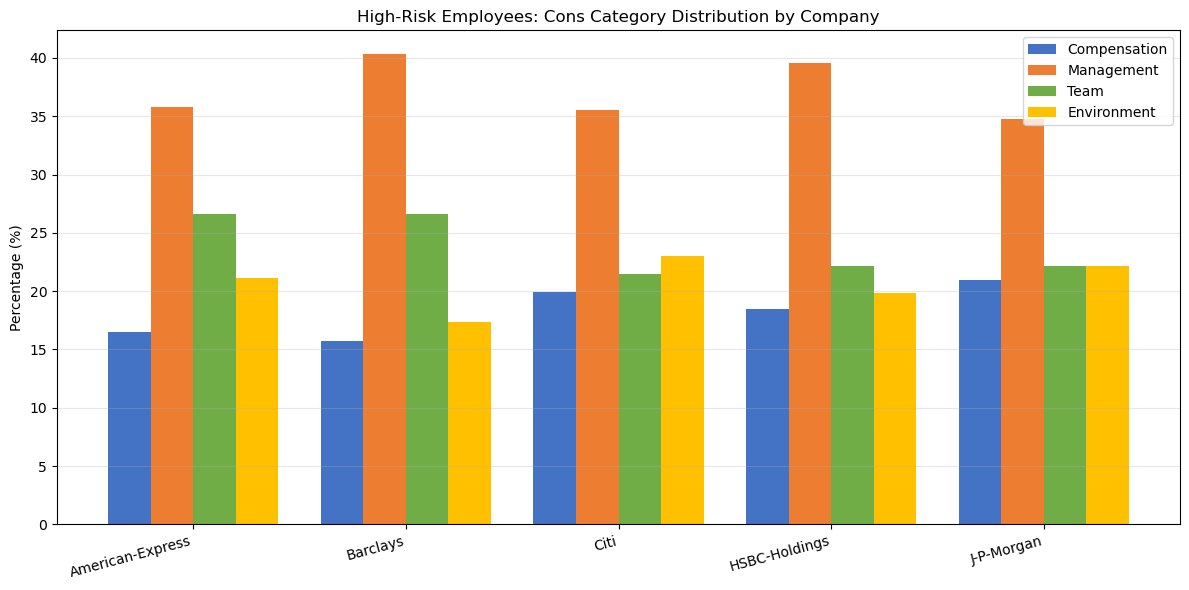


Key Findings:
American-Express: Top concern is "Management" (35.8%)
Barclays: Top concern is "Management" (40.3%)
Citi: Top concern is "Management" (35.5%)
HSBC-Holdings: Top concern is "Management" (39.6%)
J-P-Morgan: Top concern is "Management" (34.7%)


In [ ]:
# Part 5.4 | Analyze Turnover Reasons by Company for High-Risk Employees

# Filter high-risk employees
df_high_risk = df_cons[df_cons['target_risk'] == 1].copy()
df_high_risk_by_firm = df_high_risk.groupby('firm')['cons_category'].value_counts(normalize=True).unstack(fill_value=0) * 100

print('=' * 80)
print('High-Risk Employees: Cons Category Distribution by Company')
print('=' * 80)
print(df_high_risk_by_firm.rename(columns=CONS_CATEGORIES).round(1))

# Visualization: cons category distribution by company for high-risk employees
fig, ax = plt.subplots(figsize=(12, 6))

firms = df_high_risk_by_firm.index.tolist()
x = np.arange(len(firms))
width = 0.2

colors = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000']
for i, cat_id in enumerate(range(4)):
    values = df_high_risk_by_firm[cat_id].values if cat_id in df_high_risk_by_firm.columns else [0] * len(firms)
    ax.bar(x + i * width, values, width, label=CONS_CATEGORIES[cat_id], color=colors[i])

ax.set_ylabel('Percentage (%)')
ax.set_title('High-Risk Employees: Cons Category Distribution by Company')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(firms, rotation=15, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cons_category_by_company.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings
print('\n' + '=' * 80)
print('Key Findings:')
print('=' * 80)
for firm in firms:
    firm_data = df_high_risk_by_firm.loc[firm]
    top_cat = firm_data.idxmax()
    top_pct = firm_data.max()
    print(f'{firm}: Top concern is "{CONS_CATEGORIES[top_cat]}" ({top_pct:.1f}%)')